# GMM Simulator Tutorial: Inferring the Component Mean with LF2I

In [67]:
import torch

In [ ]:
# SETTINGS

LIKELIHOOD_COV   = 0.01   # shared variance for both GMM components
N_COMPONENTS     = 2       # symmetric bimodal: N(-θ, σ²) + N(+θ, σ²)

PRIOR            = 'gaussian'
PRIOR_LOC = 0
PRIOR_COV = 0.1
PARAM_SPACE_BOUNDS = {'low': -3.0, 'high': 3.0}

PARAM_DIM  = 2   # θ is scalar
DATA_DIM   = 1   # each observation X is scalar
BATCH_SIZE = 1   # one observed sample per true parameter

CONFIDENCE_LEVEL = 0.90
POI_GRID_SIZE    = 1_000   # evaluation grid points over [low, high]

B       = 20_000   # simulations for test-statistic estimation
B_PRIME = 10_000   # simulations for p-value calibration

In [71]:
# mean_fn
def mean_fn(params):
    theta0 = params[:, 0]
    theta1 = params[:, 1]

    mu0 = theta0.unsqueeze(-1)
    mu1 = theta1.unsqueeze(-1)

    return torch.stack([mu0, mu1], dim=1)  # (size, 2, 1)

In [72]:
from lf2i.simulator.gmm import GaussianMixture

In [74]:
simulator = GaussianMixture(
    likelihood_cov=LIKELIHOOD_COV,
    prior=PRIOR,
    poi_space_bounds=PARAM_SPACE_BOUNDS,
    poi_grid_size=POI_GRID_SIZE,
    poi_dim=PARAM_DIM,
    data_dim=DATA_DIM,
    batch_size=BATCH_SIZE,
    n_components=N_COMPONENTS,
    mean_fn=mean_fn,
    prior_kwargs={'loc': PRIOR_LOC, 'cov': PRIOR_COV}
)

# Ensure poi_grid is always (N, poi_dim) — avoids downstream shape issues
if simulator.poi_grid.dim() == 1:
    simulator.poi_grid = simulator.poi_grid.unsqueeze(-1)

print(f"Grid shape : {simulator.poi_grid.shape}")   # (1000, 1)
print(f"Grid range : [{simulator.poi_grid.min():.2f}, {simulator.poi_grid.max():.2f}]")

Grid shape : torch.Size([1024, 2])
Grid range : [-3.00, 3.00]


In [75]:
import matplotlib.pyplot as plt
import numpy as np

In [76]:
true_param_consistent = torch.Tensor([1.0, 1.0])
true_param_inconsistent = torch.Tensor([2.7, 2.7])

observed_x_consistent = simulator._make_likelihood(true_param_consistent.unsqueeze(0)).sample()[0]

observed_x_inconsistent = simulator._make_likelihood(true_param_inconsistent.unsqueeze(0)).sample()[0]

In [77]:
from lf2i.inference import LF2I
from lf2i.test_statistics import Posterior
from sbi.inference import SNPE
from sbi.neural_nets import posterior_nn

lf2i = LF2I(
    test_statistic=Posterior(
        estimator=SNPE(),
        poi_dim=PARAM_DIM
    )
)

In [78]:
observed_x = torch.vstack([
    observed_x_consistent.unsqueeze(0),
    observed_x_inconsistent.unsqueeze(0),
])

In [79]:
confidence_region = lf2i.inference(
    x=observed_x,
    evaluation_grid=simulator.poi_grid,
    confidence_level=CONFIDENCE_LEVEL,
    calibration_method='critical-values',
    simulator=simulator,
    b=B,
    b_prime=B_PRIME
)

Estimating test statistic ...
 Neural network successfully converged after 62 epochs.
Calibration ...


Evaluating posterior for 10000 points ...: 100%|██████████| 10000/10000 [03:07<00:00, 53.46it/s]


Retraining calibration...


Fitting 5 folds for each of 25 candidates, totalling 125 fits

Constructing confidence regions ...


Evaluating posterior for 2 points ...: 100%|██████████| 2/2 [00:36<00:00, 18.37s/it]


Creating set 0...


In [80]:
from lf2i.plot.parameter_regions import plot_parameter_regions
from lf2i.utils.other_methods import hpd_region

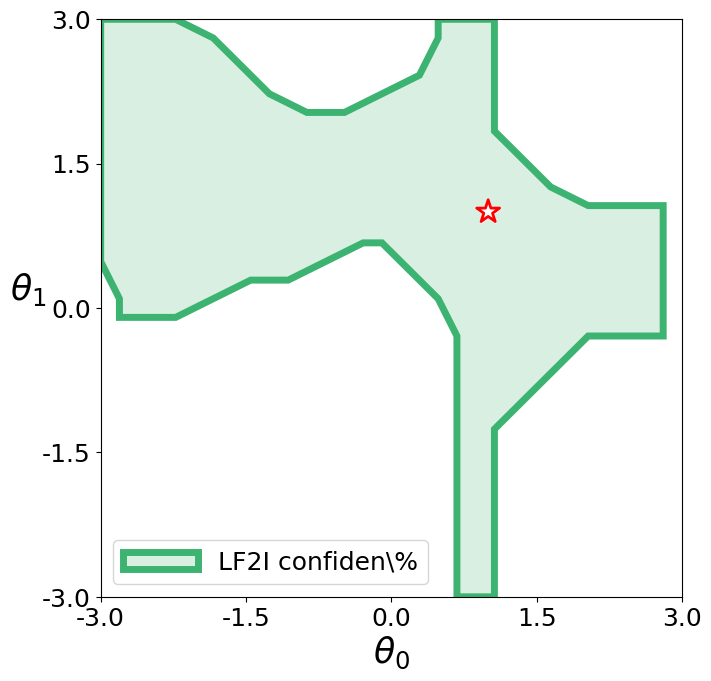

In [81]:
plot_parameter_regions(
    confidence_region[0],     # indicators for first observation
    param_dim=PARAM_DIM,
    true_parameter=true_param_consistent,
    param_names=['theta0', 'theta1'],
    parameter_space_bounds={'theta0': simulator.poi_space_bounds, 'theta1': simulator.poi_space_bounds},
    alpha_shape=True,
    alpha=2,
    scatter=False,
    figsize=(7.5, 7.5),
    colors=['mediumseagreen'],
    region_names=['LF2I confidence set'],
)

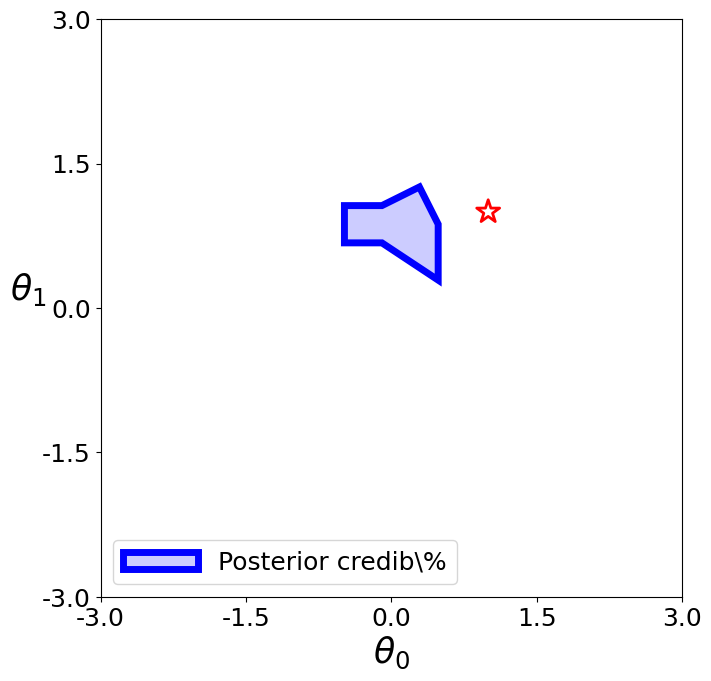

In [82]:
plot_parameter_regions(
    hpd_region(
        posterior=lf2i.test_statistic.estimator,
        param_grid=simulator.poi_grid,
        x=observed_x_consistent,
        credible_level=CONFIDENCE_LEVEL
    )[1],
    param_dim=PARAM_DIM,
    true_parameter=true_param_consistent,
    param_names=['theta0', 'theta1'],
    parameter_space_bounds={'theta0': simulator.poi_space_bounds, 'theta1': simulator.poi_space_bounds},
    alpha_shape=True,  # contour,
    alpha=2,  # hyperparameter for contour (the lower, the more it converges to a convex hull)
    scatter=False,  # don't plot evaluation points
    figsize=(7.5, 7.5),
    colors=['blue'],
    region_names=['Posterior credible set']
)

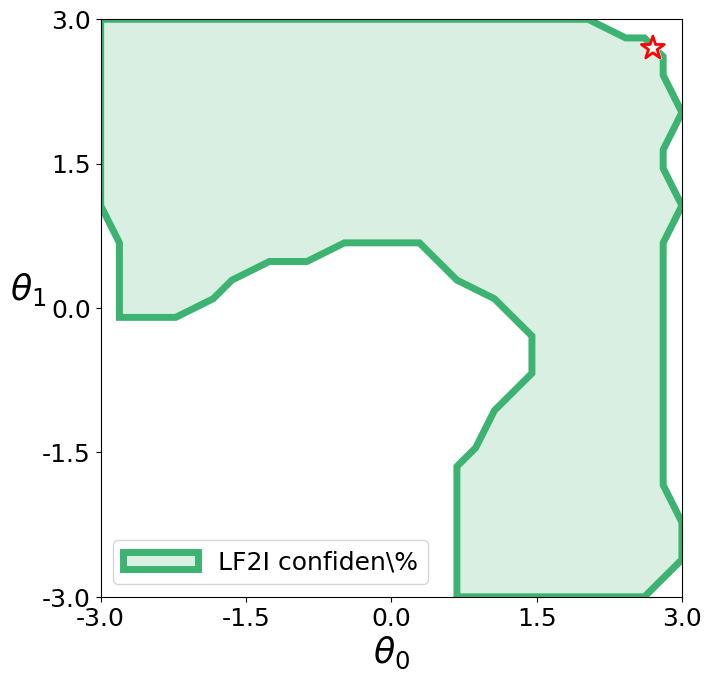

In [83]:
plot_parameter_regions(
    confidence_region[1],     # indicators for first observation
    param_dim=PARAM_DIM,
    true_parameter=true_param_inconsistent,
    param_names=['theta0', 'theta1'],
    parameter_space_bounds={'theta0': simulator.poi_space_bounds, 'theta1': simulator.poi_space_bounds},
    alpha_shape=True,
    alpha=2,
    scatter=False,
    figsize=(7.5, 7.5),
    colors=['mediumseagreen'],
    region_names=['LF2I confidence set'],
)

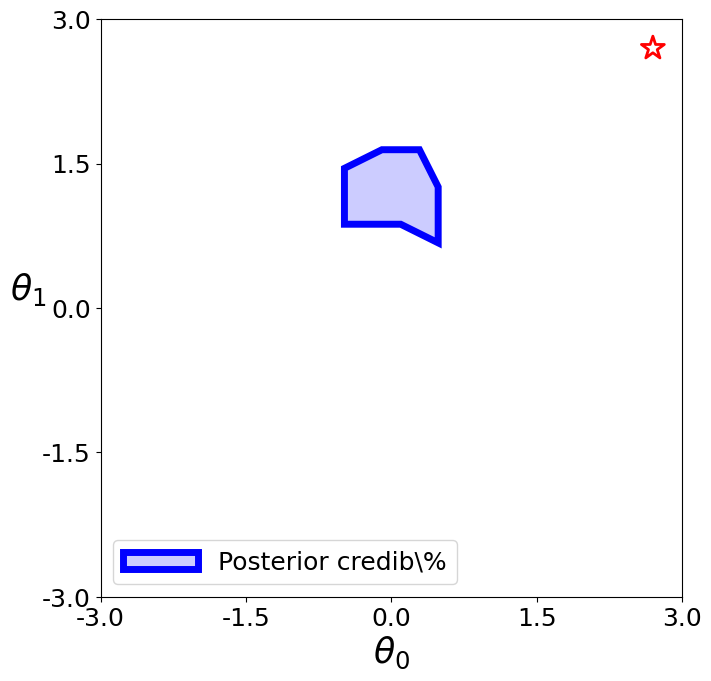

In [84]:
plot_parameter_regions(
    hpd_region(
        posterior=lf2i.test_statistic.estimator,
        param_grid=simulator.poi_grid,
        x=observed_x_inconsistent,
        credible_level=CONFIDENCE_LEVEL
    )[1],
    param_dim=PARAM_DIM,
    true_parameter=true_param_inconsistent,
    param_names=['theta0', 'theta1'],
    parameter_space_bounds={'theta0': simulator.poi_space_bounds, 'theta1': simulator.poi_space_bounds},
    alpha_shape=True,  # contour,
    alpha=2,  # hyperparameter for contour (the lower, the more it converges to a convex hull)
    scatter=False,  # don't plot evaluation points
    figsize=(7.5, 7.5),
    colors=['blue'],
    region_names=['Posterior credible set']
)

In [85]:
from lf2i.plot.coverage_diagnostics import coverage_probability_plot

In [86]:
# this will take a few minutes because it has to compute a HPD credible region for each pair of (theta, x) in the simulated set
# the code is parallelized, but one can make it faster by decreasing the argument num_p_levels, which controls the number of level sets examined to construct the HPD region
# note that this might cause the credibility level of the HPD region to be only approximately equal to CONFIDENCE LEVEL
diagnostic_estimator, parameters, mean_proba, upper_proba, lower_proba, sizes = lf2i.diagnostics(
    region_type='posterior',
    simulator=simulator,
    b_double_prime=10_000,
    evaluation_grid=simulator.poi_grid.reshape(-1, PARAM_DIM),
    confidence_level=CONFIDENCE_LEVEL,
    posterior_estimator=lf2i.test_statistic.estimator,
    n_jobs=-2
)

Computing indicators for 10000 credible regions: 100%|██████████| 10000/10000 [03:25<00:00, 48.55it/s]


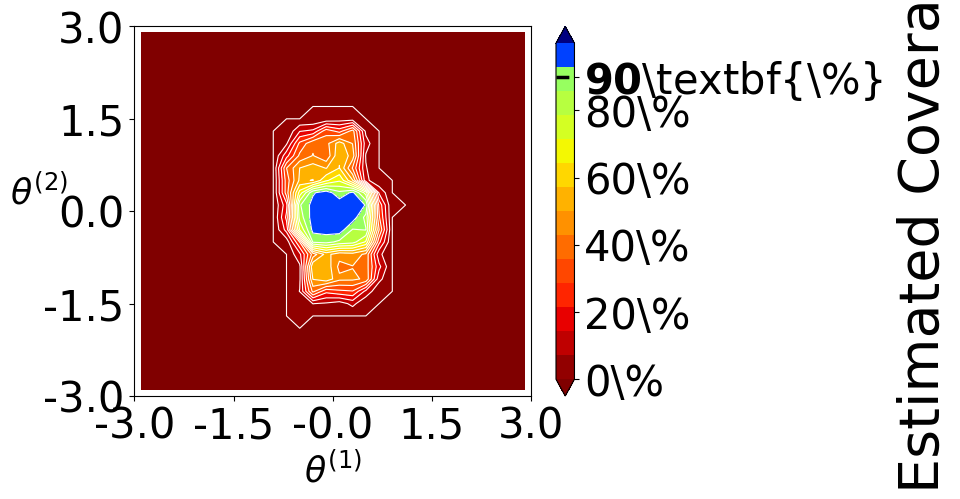

In [87]:
coverage_probability_plot(
    parameters=parameters,
    coverage_probability=mean_proba, 
    upper_proba=None,
    lower_proba=None,
    confidence_level=CONFIDENCE_LEVEL,
    param_dim=PARAM_DIM,
    figsize=(12, 12)
)

In [88]:
diagnostic_estimator, parameters, mean_proba, upper_proba, lower_proba = lf2i.diagnostics(
    region_type='lf2i',
    confidence_level=CONFIDENCE_LEVEL,
    calibration_method='critical-values',
    simulator=simulator,
    b_double_prime=10_000,
)

Evaluating posterior for 10000 points ...: 100%|██████████| 10000/10000 [03:08<00:00, 53.10it/s]


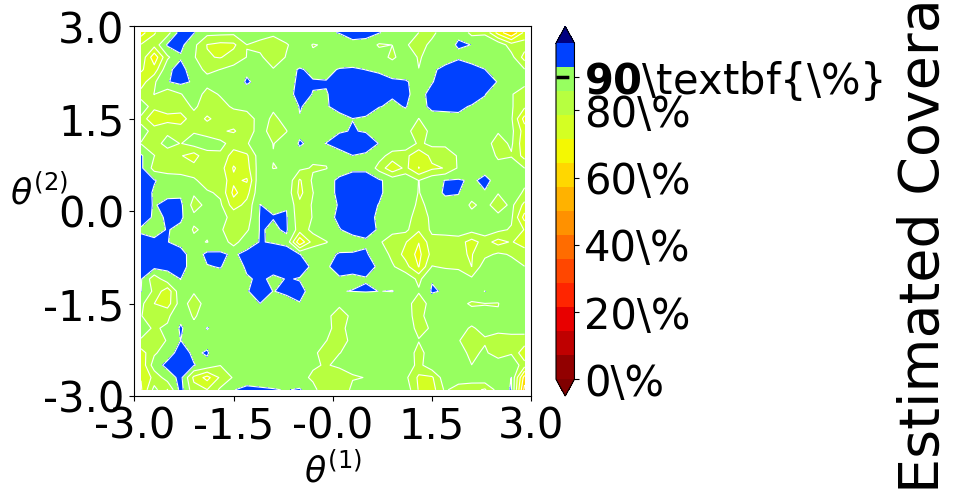

In [89]:
coverage_probability_plot(
    parameters=parameters,
    coverage_probability=mean_proba, 
    upper_proba=None,
    lower_proba=None,
    confidence_level=CONFIDENCE_LEVEL,
    param_dim=PARAM_DIM,
    figsize=(12, 10)
)